In [42]:
#TODO results are outdated for unsuprevised casse, udpate to save based on best detector name.

In [43]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from its.search import InverseTransformationSearch
from search.parallel_gradient import ParallelGradientDescent
from utils.affine_transforms_old import AffineTransformation2D
from utils.sampling import BatchNegativeSampler

#torch.cuda.is_available = lambda: False
#device = torch.device("cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "bigger_mnist"

default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",
}



architecture = default_architecutre_mapping[dataset]
budget = None

In [44]:
import torch
import numpy as np
import tqdm
from numpy.testing import assert_array_equal, assert_allclose

def test_loader_determinism(loader, num_batches_to_test: int = 5):
    """Tests if iterating a PyTorch DataLoader twice yields identical results."""

    print(f"Testing loader determinism over the first {num_batches_to_test} batches...")

    # --- Run 1: Collect first N batches ---
    run1_data, run1_labels = [], []
    loader_iter1 = iter(loader)
    for _ in tqdm.tqdm(range(num_batches_to_test), desc="Run 1"):
        try:
            x, y = next(loader_iter1)
            run1_data.append(x)
            run1_labels.append(y)
        except StopIteration:
            break

    # --- Run 2: Collect first N batches ---
    run2_data, run2_labels = [], []
    loader_iter2 = iter(loader)
    for _ in tqdm.tqdm(range(num_batches_to_test), desc="Run 2"):
        try:
            x, y = next(loader_iter2)
            run2_data.append(x)
            run2_labels.append(y)
        except StopIteration:
            break

    # --- Comparison ---
    if len(run1_data) != len(run2_data):
        print(f"❌ ERROR: Run 1 yielded {len(run1_data)} batches, Run 2 yielded {len(run2_data)} batches.")
        return False

    for i in range(len(run1_data)):
        # 1. Check Labels (must be exact)
        try:
            assert_array_equal(run1_labels[i].numpy(), run2_labels[i].numpy())
        except AssertionError as e:
            print(f"❌ FAILED on Batch {i}: Labels are not identical.")
            print(e)
            return False

        # 2. Check Data (allowing for float precision, though it should be exact)
        try:
            # Use allclose with a small tolerance for floating point numbers
            # If the data includes non-deterministic noise/augmentations, this will fail.
            assert torch.allclose(run1_data[i], run2_data[i], atol=1e-6)
        except AssertionError as e:
            print(f"❌ FAILED on Batch {i}: Data tensors are not identical (max diff: {(run1_data[i] - run2_data[i]).abs().max()}).")
            print("This indicates randomness in the data loading or augmentation pipeline.")
            return False

    print("✅ SUCCESS: Data loader is deterministic for the tested batches.")
    return True



In [45]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)

dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

In [46]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']

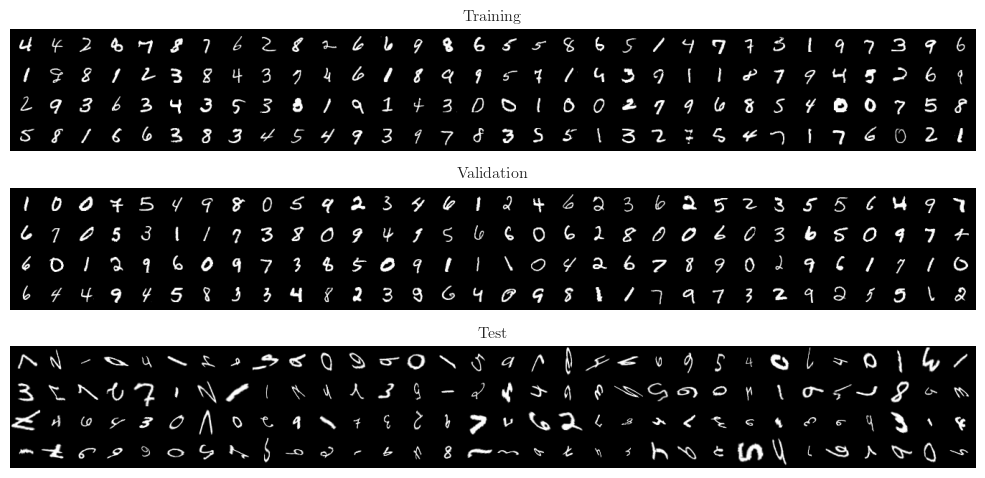

In [47]:
x = next(iter(test_loader_transformed))[0]

batch_size = next(iter(train_loader))[0].shape[0]

from utils.eval.vis import vis_dataset, plt_setup_latex

vis_dataset(train_loader, val_loader, test_loader_transformed)
from experiment_thesis.main import train_and_get_model, train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture,
                                "comparison_unsupervised")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path, transform_name, f"{safe}.json")

def cache_path(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(embedding_cache_path, dataset, architecture, transform_name, f"{safe}_embedding_cache.npz")

In [48]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small.safetensors


(FlexibleResNet(
   (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
   (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (stem_act): GELU(approximate='none')
   (stages): ModuleList(
     (0): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (act): GELU(approximate='none')
       )
     )
     (1): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [49]:
model.eval().to(device)

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [50]:
#check main model
res = evaluate_base_model(model, test_loader_transformed, device)
print(res)
res = evaluate_base_model(model, test_loader, device)
print(res)

{'accuracy': 0.37689998745918274, 'f2_macro': 0.37094762921333313, 'f2_micro': 0.37689998745918274, 'f2_weighted': 0.3730011582374573}


{'accuracy': 0.9955999851226807, 'f2_macro': 0.9955340027809143, 'f2_micro': 0.9955999851226807, 'f2_weighted': 0.9955984354019165}


In [51]:
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]

from utils.replacer import replace_rotation_transforms_2vec


from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
    name=dataset_info.transform_seq_name,
    resample_method=dataset_info.resample_method,
    init_method="sobol"
).to(device)

if dataset == "modelnet10":
    transform_seq = replace_rotation_transforms_2vec(transform_seq)

In [52]:
print(transform_seq.transformations)

[<utils.transforms.rotation.Rotation2D object at 0x000001F80FF35D50>, <utils.transforms.shear.DirectedShear object at 0x000001F81148EE90>, <utils.transforms.shear.DirectedShear object at 0x000001F81148EEF0>, <utils.transforms.scale.DirectedScale object at 0x000001F81148DFF0>, <utils.transforms.scale.DirectedScale object at 0x000001F81148E290>]


In [53]:
from experiment_thesis.dataset_preperation.basic_networks import make_deterministic
make_deterministic(model)



In [54]:
from experiment_thesis.dataset_preperation.get_dataset import get_layer_embedding_cache_config,create_layer_embedding_cache
cache_config = get_layer_embedding_cache_config(dataset, architecture,transform_name=None,dataset_info=dataset_info)
train_cache =create_layer_embedding_cache(model, train_loader_no_shuffle,cache_config, embedding_cache_path, device=device)


In [55]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [56]:
from experiment_thesis.ood import base_prepare

base_prepare.OOD_PARAM_SAMPLERS.keys()

dict_keys(['energy', 'energy_ts', 'max_logit', 'entropy', 'max_softmax', 'differentiable_max_softmax', 'adjusted_entropy', 'Max Logit', 'MSP', 'cross_entropy', 'ash', 'gradnorm', 'laplace_prob', 'laplace_energy', 'laplace_variance', 'laplace_mutual_information', 'laplace_entropy_plus_mi', 'laplace_entropy', 'laplace_weighted', 'laplace_mi', 'laplace_best_criterion', 'laplace_entropy_gridsearch', 'laplace_energy_multi', 'mc_dropout_prob', 'mc_dropout_variance', 'mc_dropout_mi', 'mc_dropout_energy', 'mc_dropout_last_layer_prob', 'mc_dropout_last_layer_variance', 'mc_dropout_last_layer_mi', 'mc_dropout_last_layer_energy', 'mc_batchnorm_prob', 'mc_batchnorm_variance', 'mc_batchnorm_mi', 'mc_batchnorm_energy', 'mc_dropout_best_criterion', 'mc_batchnorm_best_criterion', 'mc_dropout_last_layer_best_criterion', 'react', 'react_all', 'dice', 'gaussian', 'gmm', 'gram', 'kde', 'kl_matching', 'faiss_knn', 'faiss_per_class_knn', 'knn', 'per_class_knn', 'knn_trap', 'per_class_knn_trap', 'knn_mixed',

In [57]:
detectors = ["knn","per_class_knn", "knn_mixed","per_class_knn_mixed","knn_mixed_faiss","knn_itf","vim","react","dice","ash","she","laplace_mi","laplace_energy","laplace_weighted","trust_score","openmax","mahalanobis","rmd","class_prototype","react_all","energy","per_class_prototype","single_mahalanobis","single_rmd","single_mahalanobis_individual","single_rmd_individual","mahalanobis_individual","rmd_individual","prototype_multi", "laplace_entropy","adjusted_entropy","nn_guided","nn_guided_one"]
#dont do kde to expensive, and not better.
#global protoype makes no sense over class based protoype
# lof fit is to slow, gmm is even slower or fails due to size
# gram runs out of main memory,

detectors_parameterless = ["energy_ts","entropy","kl_matching","laplace_entropy_gridsearch"]
detectors = detectors + detectors_parameterless
from experiment_thesis.dataset_preperation.basic_networks import FlexibleResNet
if not isinstance(model,FlexibleResNet):
    #remove ash and react_all as they only work with resnets
    detectors.remove("ash")
    detectors.remove("react_all")
    if "react" not in detectors:
        detectors.append("react")
    detectors.append("ash_last")



In [58]:
# python
import os
import json
import math
import torch
from typing import Tuple, Optional, Any, Dict

from experiment_thesis.ood.base_prepare import create_ood_problem, get_default_ood_params

def find_best_detector_and_instantiate(
    base_results_dir: str,
    detectors: list,
    model,
    train_cache,
    transform_seq_arg,
    dataset_info,
    architecture: str,
    device,
    val_id_loader,
    val_ood_loader,
    prefer_second: Optional[str] = None,
) -> Tuple[
    Optional[str],
    Optional[Any],
    Optional[Dict[str, float]],
    Optional[str],
    Optional[Any],
    Optional[Dict[str, float]],
]:
    """
    Find best detector by recorded `accuracy_mean` (preferring mean) and instantiate its OOD problem.
    Returns:
      (best_detector, best_problem, best_score_dict, second_choice, second_problem, second_score_dict)
    where score dict is `{"mean": float, "se": float}` (values may be math.nan if missing).
    """

    def _load_score(det_name: str) -> Optional[Dict[str, float]]:
        eval_path = os.path.join(base_results_dir, det_name, "eval_results.json")
        eval_default_path = os.path.join(base_results_dir, det_name, "eval_results_default.json")

        for p in (eval_path, eval_default_path):
            if os.path.exists(p):
                try:
                    with open(p, "r") as f:
                        data = json.load(f)
                except Exception:
                    continue
                mean = data.get("accuracy_mean")
                se = data.get("accuracy_se", data.get("accuracy_std"))  # prefer se, fall back to std
                # normalize types
                mean_val = float(mean) if isinstance(mean, (int, float)) else math.nan
                se_val = float(se) if isinstance(se, (int, float)) else math.nan
                if not math.isnan(mean_val):
                    return {"mean": mean_val, "se": se_val}
        return None

    # 1) scan detectors for optimized accuracy (use mean)
    best_detector: Optional[str] = None
    best_score_val = -math.inf
    best_score_dict: Optional[Dict[str, float]] = None
    for det in detectors:
        score_dict = _load_score(det)
        if score_dict is None:
            continue
        mean = score_dict["mean"]
        if mean > best_score_val:
            best_score_val = mean
            best_detector = det
            best_score_dict = score_dict

    # If we didn't find any valid scored detector, return Nones
    if best_detector is None:
        return None, None, None, None, None, None

    # 2) load best params for best_detector (or default if no params file)
    det_dir = os.path.join(base_results_dir, best_detector)
    params_path = os.path.join(det_dir, "best_params.json")
    best_params = None
    if os.path.exists(params_path):
        try:
            with open(params_path, "r") as f:
                best_params = json.load(f)
        except Exception:
            best_params = None

    if best_params is None:
        best_params = get_default_ood_params(best_detector)

    # 3) try load saved model states for this detector (if any)
    best_model_params = []
    prefix = os.path.join(det_dir, "best_model")
    i = 0
    while os.path.exists(f"{prefix}_{i}.pt"):
        try:
            best_model_params.append(torch.load(f"{prefix}_{i}.pt", map_location="cpu"))
        except Exception:
            pass
        i += 1

    final_kwargs = {
        "model": model,
        "train_cache": train_cache,
        "transform_seq": transform_seq_arg,
        "dataset_info": dataset_info,
        "architecture": architecture,
        "device": str(device),
        "val_id_loader": val_id_loader,
        "val_ood_loader": val_ood_loader,
    }
    if best_model_params:
        final_kwargs["model_params"] = best_model_params

    best_problem = create_ood_problem(best_detector, best_params, **final_kwargs)

    # 4) prepare the second problem: choose the better of energy vs entropy by recorded performance
    if prefer_second and prefer_second in detectors:
        second_choice = prefer_second
        second_score_dict = _load_score(second_choice)
    else:
        candidates = [d for d in ("energy", "entropy") if d in detectors]
        second_choice = None
        best_cand_val = -math.inf
        second_score_dict = None
        for c in candidates:
            sdict = _load_score(c)
            if sdict is not None and sdict["mean"] > best_cand_val:
                best_cand_val = sdict["mean"]
                second_choice = c
                second_score_dict = sdict

    # avoid selecting same detector twice
    if second_choice == best_detector:
        other = "entropy" if best_detector == "energy" else "energy"
        if other in detectors:
            other_score = _load_score(other)
            if other_score is not None:
                second_choice = other
                second_score_dict = other_score
            else:
                second_choice = None
                second_score_dict = None
        else:
            second_choice = None
            second_score_dict = None

    if second_choice is None:
        second_problem = None
    else:
        det2_dir = os.path.join(base_results_dir, second_choice)
        params2_path = os.path.join(det2_dir, "best_params.json")
        params2 = None
        if os.path.exists(params2_path):
            try:
                with open(params2_path, "r") as f:
                    params2 = json.load(f)
            except Exception:
                params2 = None
        if params2 is None:
            params2 = get_default_ood_params(second_choice)

        model_params2 = []
        prefix2 = os.path.join(det2_dir, "best_model")
        j = 0
        while os.path.exists(f"{prefix2}_{j}.pt"):
            try:
                model_params2.append(torch.load(f"{prefix2}_{j}.pt", map_location="cpu"))
            except Exception:
                pass
            j += 1

        final_kwargs2 = dict(final_kwargs)
        if model_params2:
            final_kwargs2["model_params"] = model_params2

        second_problem = create_ood_problem(second_choice, params2, **final_kwargs2)

    return best_detector, best_problem, best_score_dict, second_choice, second_problem, second_score_dict

# Example call (update unpacking to 6 values)
base_results_dir = os.path.join(
    current_path,
    "experiment_files",
    "results",
    "comparison_unsupervised",
    str(dataset),
    str(architecture),
    getattr(dataset_info, "transform_seq_name", "default"),
)

best_detector, best_problem, best_score, second_choice, second_problem, second_score = find_best_detector_and_instantiate(
    base_results_dir=base_results_dir,
    detectors=detectors,
    model=model,
    train_cache=train_cache,
    transform_seq_arg=transform_seq,
    dataset_info=dataset_info,
    architecture=architecture,
    device=device,
    val_id_loader=val_loader_transformed,
    val_ood_loader=val_loader_transformed,
)

In [59]:
#store the best detector for each dataset to ensure we use the same for all experiments



In [60]:
#here we do the following calculate the accuracy on the test set, then calculate on the transformed test set. We also store the confidence valeus
#then we do the optimiztation to find which ones we can transform to get better accuracy.
#we then draw the curve over the threshold when we switch from doing no optimization to doing optimization, this should drop the accuracy on the test set but increase on the transformed test set.



In [61]:
conf = best_problem.confidence_module

In [62]:
import os, json
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparison_augmented_models")
result_path = os.path.join(results_dir_path, transform_name, f"{modelname}_augmented.json")
with open(result_path, "r") as f: results = json.load(f)
print(results)

augmnet_acc_on_in_dist = results.get("original_test_results", None)["accuracy"]

{'modelname': 'bigger_mnist_resnet_small_augmented', 'transformed_test_results': {'accuracy': 0.9871000051498413, 'f2_macro': 0.9869429469108582, 'f2_micro': 0.9871000051498413, 'f2_weighted': 0.987095832824707}, 'original_test_results': {'accuracy': 0.9916999936103821, 'f2_macro': 0.9916419982910156, 'f2_micro': 0.9916999936103821, 'f2_weighted': 0.9916967153549194}}


In [63]:
import os
import numpy as np
import torch
import tqdm
import matplotlib.pyplot as plt
from typing import Dict


@torch.no_grad()
def calculate_confidences_and_cache(
    optimizer,
    best_problem,
    conf_fn,
    test_loader,
    test_loader_transformed,
    device,
    n_runs: int = 5,
    cache_path: str = "cached_confidences.npz",
    force_recompute: bool = False,
    augment_true_func=None,
) -> Dict[str, np.ndarray]:
    """
    Calculates and caches:
      - base confidence/correctness (without optimization)
      - optimized confidence/correctness (repeated n_runs times for stochastic optimizer)
    If `cache_path` exists, loads results unless `force_recompute=True`.
    """
    test_loader_determinism(test_loader)
    test_loader_determinism(test_loader_transformed)

    if os.path.exists(cache_path) and not force_recompute:
        print(f"✅ Loading cached results from {cache_path}")
        return dict(np.load(cache_path, allow_pickle=True))

    print("=== Calculating base confidences (no optimization) ===")

    def eval_conf(loader, augment_func=None):
        all_conf, correct = [], []
        for x_test, y_test in tqdm.tqdm(loader):
            x_test = x_test.to(device)
            if augment_func is not None:
                x_test = augment_func(x_test)
            conf_values, logits = conf_fn(x_test)
            if logits is None:
                logits = model(x_test)
            pred_y = torch.argmax(logits, dim=1).cpu()
            correct.append((pred_y == y_test).numpy())
            all_conf.append(conf_values.cpu().numpy())
        return np.concatenate(correct), np.concatenate(all_conf)

    correct_predicted, all_conf = eval_conf(test_loader, augment_true_func)
    correct_predicted_transformed, all_conf_transformed = eval_conf(test_loader_transformed)

    results = {
        "correct_predicted": correct_predicted,
        "all_conf": all_conf,
        "correct_predicted_transformed": correct_predicted_transformed,
        "all_conf_transformed": all_conf_transformed,
    }

    print("\n=== Running probabilistic optimizer ===")

    optimized_correct_runs, optimized_conf_runs = [], []
    optimized_correct_runs_t, optimized_conf_runs_t = [], []

    for run_idx in range(n_runs):
        print(f"\n--- Optimization run {run_idx + 1}/{n_runs} ---")

        correct_run, conf_run = [], []
        for x_test, y_test in tqdm.tqdm(test_loader, desc=f"Test run {run_idx+1}"):
            x_test = x_test.to(device)
            p, error, _ = optimizer.optimize(best_problem, x_test)
            x_optimized = best_problem.transform_sequence.transform(x_test, p)
            conf_values, logits = conf_fn(x_optimized)
            if logits is None:
                logits = model(x_optimized)
            pred_y = torch.argmax(logits, dim=1).cpu()
            correct_run.append((pred_y == y_test).numpy())
            conf_run.append(conf_values.cpu().numpy())
        optimized_correct_runs.append(np.concatenate(correct_run))
        optimized_conf_runs.append(np.concatenate(conf_run))

        correct_run_t, conf_run_t = [], []
        for x_test, y_test in tqdm.tqdm(test_loader_transformed, desc=f"Transformed run {run_idx+1}"):
            x_test = x_test.to(device)
            p, error, _ = optimizer.optimize(best_problem, x_test)
            x_optimized = best_problem.transform_sequence.transform(x_test, p)
            conf_values, logits = conf_fn(x_optimized)
            if logits is None:
                logits = model(x_optimized)
            pred_y = torch.argmax(logits, dim=1).cpu()
            correct_run_t.append((pred_y == y_test).numpy())
            conf_run_t.append(conf_values.cpu().numpy())
        optimized_correct_runs_t.append(np.concatenate(correct_run_t))
        optimized_conf_runs_t.append(np.concatenate(conf_run_t))

    results["optimized_correct_predicted"] = np.stack(optimized_correct_runs, axis=1)
    results["optimized_all_conf"] = np.stack(optimized_conf_runs, axis=1)
    results["optimized_correct_predicted_transformed"] = np.stack(optimized_correct_runs_t, axis=1)
    results["optimized_all_conf_transformed"] = np.stack(optimized_conf_runs_t, axis=1)

    np.savez_compressed(cache_path, **results)
    print(f"\n💾 Cached results saved to: {cache_path}")

    return results


import numpy as np
import matplotlib.pyplot as plt
W=plt_setup_latex()

import numpy as np
import matplotlib.pyplot as plt
W = plt_setup_latex()

def plot_confidence_threshold_results(
    results: dict,
    dataset_name: str = "Dataset",
    use_only_improved: bool = True,
    improvement_metric: str = "confidence",
    relative_improvement: float = 0.0,
    ci_multiplier: float = 1.96,
    lower_quantile: float = 0.001,
    upper_quantile: float = 1.0,
    plot_ratio=True,
    save_path =None,
):
    """
    Plots accuracy and optimization ratio vs confidence threshold with confidence intervals.
    - improvement_metric must be 'confidence'.
    - relative_improvement is a fraction of (max_conf - min_conf) to accept optimized predictions.
    - lower_quantile / upper_quantile are used to set the x-axis limits (not to filter data).
    """

    import numpy as np
    import matplotlib.pyplot as plt

    if improvement_metric != "confidence":
        raise ValueError("Only improvement_metric='confidence' is supported.")

    # ---- Load data ----
    all_conf = results["all_conf"]
    all_conf_t = results["all_conf_transformed"]
    corr = results["correct_predicted"]
    corr_t = results["correct_predicted_transformed"]
    opt_corr = results["optimized_correct_predicted"]
    opt_corr_t = results["optimized_correct_predicted_transformed"]
    #cor is array of bools whether prediction was correct


    opt_conf = results["optimized_all_conf"]
    opt_conf_t = results["optimized_all_conf_transformed"]

    # ---- Thresholds ----
    min_conf = float(min(all_conf.min(), all_conf_t.min()))
    max_conf = float(max(all_conf.max(), all_conf_t.max()))
    conf_range = max_conf - min_conf
    if conf_range <= 0 and relative_improvement > 0:
        raise ValueError("confidence range is zero, cannot apply relative_improvement")

    ql = np.quantile(all_conf_t, lower_quantile)

    # This replaces the 'searchsorted' logic by pre-calculating it mathematically
    qh = np.quantile(all_conf_t, upper_quantile)

    if qh <= ql:
        # Fallback if quantiles are identical (rare edge case in low variety data)
        qh = float(max(all_conf.max(), all_conf_t.max()))


    thresholds = np.linspace(ql, qh, 400)
    n_runs = opt_conf.shape[1]

    acc_orig_runs, acc_trans_runs = [], []
    ratio_orig_runs, ratio_trans_runs = [], []

    # ---- Compute accuracies and ratios per threshold ----
    for r in range(n_runs):
        acc_o, acc_t = [], []
        ratio_o, ratio_t = [], []

        for thr in thresholds:
            applied_o = all_conf <= thr
            applied_t = all_conf_t <= thr

            improved_o = opt_conf[:, r] >= all_conf
            improved_t = opt_conf_t[:, r] >= all_conf_t

            if relative_improvement > 0.0:
                rel_imp_o = (opt_conf[:, r] - all_conf) / conf_range
                rel_imp_t = (opt_conf_t[:, r] - all_conf_t) / conf_range
                improved_o = np.logical_and(improved_o, rel_imp_o >= relative_improvement)
                improved_t = np.logical_and(improved_t, rel_imp_t >= relative_improvement)

            # Count optimizations attempted (before any rejection)
            attempted_o = np.logical_and(applied_o, improved_o)
            attempted_t = np.logical_and(applied_t, improved_t)

            ratio_o.append(applied_o.mean())  # NumPy bool array -> mean gives fraction True
            ratio_t.append(applied_t.mean())

            # Now optionally reject optimized predictions
            if use_only_improved:
                use_opt_o = attempted_o
                use_opt_t = attempted_t
            else:
                use_opt_o = applied_o
                use_opt_t = applied_t

            #use now specifies wether we actually use the result from optimization or not o is original t is transformed

            final_corr_o = np.where(use_opt_o, opt_corr[:, r], corr)
            final_corr_t = np.where(use_opt_t, opt_corr_t[:, r], corr_t)
            acc_o.append(final_corr_o.mean())
            acc_t.append(final_corr_t.mean())


        acc_orig_runs.append(acc_o)
        acc_trans_runs.append(acc_t)
        ratio_orig_runs.append(ratio_o)
        ratio_trans_runs.append(ratio_t)

    acc_orig_runs = np.array(acc_orig_runs)
    acc_trans_runs = np.array(acc_trans_runs)
    ratio_orig_runs = np.array(ratio_orig_runs)
    ratio_trans_runs = np.array(ratio_trans_runs)

    # ---- Confidence Interval helper ----
    def compute_ci(y):
        n = y.shape[0]
        mean = y.mean(axis=0)
        if n <= 1:
            se = np.zeros_like(mean)
        else:
            se = y.std(axis=0, ddof=1) / np.sqrt(n)
        return mean, mean - ci_multiplier * se, mean + ci_multiplier * se

    # ---- Plot: Accuracy + Ratio ----
    fig, ax1 = plt.subplots(figsize=(W, W/2))
    tab10 = plt.get_cmap("tab10")
    col_o, col_t, col_ro, col_rt, col_hline = tab10(0), tab10(1), tab10(2), tab10(3), tab10(4)

    # Accuracy
    m_o, lo_o, hi_o = compute_ci(acc_orig_runs)
    m_t, lo_t, hi_t = compute_ci(acc_trans_runs)
    ax1.plot(thresholds, m_o, label="Acc Original", linewidth=2.0, color=col_o)
    ax1.fill_between(thresholds, lo_o, hi_o, alpha=0.15, color=col_o)
    ax1.plot(thresholds, m_t, label="Acc Transformed", linewidth=2.0, color=col_t)
    ax1.fill_between(thresholds, lo_t, hi_t, alpha=0.15, color=col_t)

    ax1.set_xlabel("Confidence Threshold")
    ax1.set_ylabel("Accuracy")
    ax1.grid(True, linestyle=":", alpha=0.7)
    #enable more x ticks
    import matplotlib.ticker as mticker
    ax1.yaxis.set_major_locator(mticker.MaxNLocator(nbins=10))


    # Optional horizontal line for in-distribution accuracy
    if "augmnet_acc_on_in_dist" in globals():
        ax1.axhline(
            y=augmnet_acc_on_in_dist,
            color=col_hline,
            linestyle='--',
            label='Acc Augmented',
        )
    if plot_ratio:
        # Ratio
        ax2 = ax1.twinx()
        ax2.grid(False)
        rm_o, rlo_o, rhi_o = compute_ci(ratio_orig_runs)
        rm_t, rlo_t, rhi_t = compute_ci(ratio_trans_runs)
        ax2.plot(thresholds, rm_o, linestyle="--", linewidth=1.8, color=col_ro, label="Ratio Original")
        ax2.fill_between(thresholds, rlo_o, rhi_o, alpha=0.15, color=col_ro)
        ax2.plot(thresholds, rm_t, linestyle="--", linewidth=1.8, color=col_rt, label="Ratio Transformed")
        ax2.fill_between(thresholds, rlo_t, rhi_t, alpha=0.15, color=col_rt)
        ax2.set_ylabel("Optimization Ratio")



    ax1.set_xlim(ql, qh)


    # ---- Combined legend ----
    lines1, labels1 = ax1.get_legend_handles_labels()
    if plot_ratio:
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.set_xlim(ql, qh)
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left", fontsize=8, framealpha=0.85)
    else:
        ax1.legend(lines1, labels1, loc="center left", fontsize=8, framealpha=0.85)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

    # ---- Report best accuracies ----
    best_idx_o = np.argmax(m_o)
    best_idx_t = np.argmax(m_t)
    print(f"[{dataset_name}]")
    print(f"Max acc (original): {m_o[best_idx_o]:.4f} @ thr={thresholds[best_idx_o]:.4f}")
    print(f"Max acc (transf.): {m_t[best_idx_t]:.4f} @ thr={thresholds[best_idx_t]:.4f}")


In [64]:
figure_path = os.path.join(current_path,"experiment_files","export","fig","comp_tradeoff",dataset,transform_name)
os.makedirs(figure_path, exist_ok=True)

In [65]:
from utils.transformation_problem import TransformationProblem
from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search
from confidence.control.regression import RegressionConfidence, make_aggregator
from confidence.control.regression_wrapper import RegressionWrapper
from search.shgo import SHGO
optimizer = SHGO(initial_samples=46, local_runs=2, local_max_steps=3,local_opt_kwargs={"lr":0.1})

if dataset == "tu_berlin":
    optimizer = SHGO(initial_samples=60,local_runs=1,local_max_steps=0,local_opt_kwargs={"lr":0.1})

In [66]:

import torch


In [67]:
os.makedirs(os.path.dirname(cache_path(f"cached_confidences.npz")), exist_ok=True)

In [68]:
test_loader_determinism(test_loader)
test_loader_determinism(test_loader_transformed)

Testing loader determinism over the first 5 batches...


Run 2: 100%|██████████| 5/5 [00:00<00:00, 665.47it/s]


✅ SUCCESS: Data loader is deterministic for the tested batches.
Testing loader determinism over the first 5 batches...


Run 2: 100%|██████████| 5/5 [00:00<00:00, 158.55it/s]

✅ SUCCESS: Data loader is deterministic for the tested batches.


True

Testing loader determinism over the first 5 batches...


Run 2: 100%|██████████| 5/5 [00:00<00:00, 537.95it/s]


✅ SUCCESS: Data loader is deterministic for the tested batches.
Testing loader determinism over the first 5 batches...


Run 2: 100%|██████████| 5/5 [00:00<00:00, 184.98it/s]


✅ SUCCESS: Data loader is deterministic for the tested batches.
=== Calculating base confidences (no optimization) ===


...


--- Optimization run 4/5 ---


Transformed run 4: 100%|██████████| 79/79 [00:19<00:00,  4.11it/s]



--- Optimization run 5/5 ---


Transformed run 5: 100%|██████████| 79/79 [00:18<00:00,  4.36it/s]



💾 Cached results saved to: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\embedding_cache\bigger_mnist\resnet_small\biggermnist_default\cached_confidences_knn.npz_embedding_cache.npz


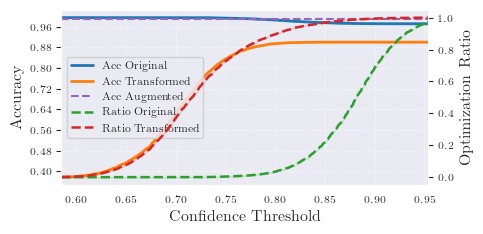

[bigger_mnist]
Max acc (original): 0.9956 @ thr=0.5850
Max acc (transf.): 0.9007 @ thr=0.8653


In [69]:
results = calculate_confidences_and_cache(
    optimizer=optimizer,
    best_problem=best_problem,
    conf_fn=conf,
    test_loader=test_loader,
    test_loader_transformed=test_loader_transformed,
    device=device,
    cache_path=cache_path(f"cached_confidences_{best_detector}.npz"),
    n_runs=5,
)
plot_confidence_threshold_results(results, dataset_name=dataset, save_path= os.path.join(figure_path,"confidence_threshold.pdf"))


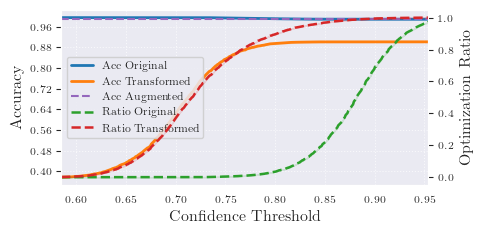

[bigger_mnist]
Max acc (original): 0.9956 @ thr=0.5850
Max acc (transf.): 0.9019 @ thr=0.8653


In [70]:
plot_confidence_threshold_results(results, dataset_name=dataset,relative_improvement=0.1, save_path= os.path.join(figure_path,"confidence_threshold_rel_imp_10.pdf"))

In [71]:
results

{'correct_predicted': array([ True,  True,  True, ...,  True,  True,  True], shape=(10000,)),
 'all_conf': array([0.92822266, 0.8691406 , 0.95947266, ..., 0.87060547, 0.8642578 ,
        0.8828125 ], shape=(10000,), dtype=float32),
 'correct_predicted_transformed': array([False, False, False, ..., False, False, False], shape=(10000,)),
 'all_conf_transformed': array([0.7006836 , 0.67529297, 0.70996094, ..., 0.6982422 , 0.6699219 ,
        0.7441406 ], shape=(10000,), dtype=float32),
 'optimized_correct_predicted': array([[ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        ...,
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True]], shape=(10000, 5)),
 'optimized_all_conf': array([[0.9135742 , 0.9248047 , 0.8959961 , 0.89746094, 0.93115234],
        [0.8642578 , 0.8598633 , 0.8457031 , 0.84814453, 0.84277344],
        [0.95068

In [72]:
from utils.augments import build_default_augmentations, small_affine_augment_2d

Testing loader determinism over the first 5 batches...


Run 2: 100%|██████████| 5/5 [00:00<00:00, 832.63it/s]


✅ SUCCESS: Data loader is deterministic for the tested batches.
Testing loader determinism over the first 5 batches...


Run 2: 100%|██████████| 5/5 [00:00<00:00, 132.88it/s]


✅ SUCCESS: Data loader is deterministic for the tested batches.
=== Calculating base confidences (no optimization) ===


...


--- Optimization run 4/5 ---


Transformed run 4: 100%|██████████| 79/79 [00:18<00:00,  4.27it/s]



--- Optimization run 5/5 ---


Transformed run 5: 100%|██████████| 79/79 [00:18<00:00,  4.28it/s]



💾 Cached results saved to: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\embedding_cache\bigger_mnist\resnet_small\biggermnist_default\cached_confidences_blur_aug.npz_embedding_cache.npz


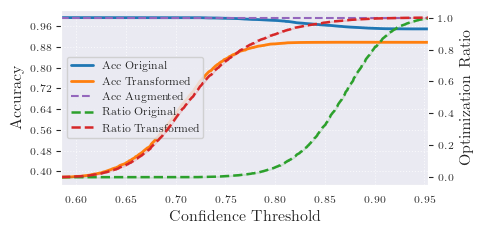

[bigger_mnist]
Max acc (original): 0.9931 @ thr=0.5850
Max acc (transf.): 0.8982 @ thr=0.8653


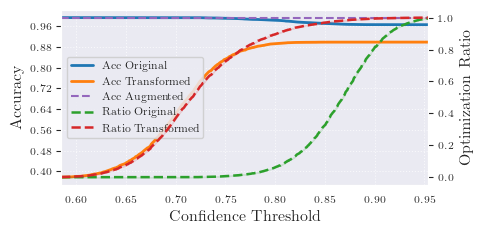

[bigger_mnist]
Max acc (original): 0.9931 @ thr=0.5850
Max acc (transf.): 0.8988 @ thr=0.8653


In [73]:
if is_image_data:
    results = calculate_confidences_and_cache(
        optimizer=optimizer,
        best_problem=best_problem,
        conf_fn=conf,
        test_loader=test_loader,
        test_loader_transformed=test_loader_transformed,
        device=device,
        n_runs=5,cache_path=cache_path(f"cached_confidences_blur_aug.npz"),
        augment_true_func=small_affine_augment_2d,
    )
    plot_confidence_threshold_results(results, dataset_name=dataset,use_only_improved=False)
    plot_confidence_threshold_results(results, dataset_name=dataset)


In [74]:
model_dir_path

'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\models'

In [75]:
from search.shgo import SHGO

optimizer_120 = SHGO(initial_samples=120-27, local_runs=3, local_max_steps=4,local_opt_kwargs={"lr":0.1})
if dataset == "tu_berlin":
    optimizer_120 = SHGO(initial_samples=120,local_runs=1,local_max_steps=0,local_opt_kwargs={"lr":0.1})

from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
from utils.sampling_strategy import TransformLatentSamplingStrategy
from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search
from utils.transformation_problem import TransformationProblem

architecture_half = architecture+"_half"

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),

    ])
else:
    transform_true_function = None
    affine_augment = None

def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


energy_model2_half = get_network(dataset_info,architecture_half, num_classes=1).to(device)
from experiment_thesis.main import train_or_load_energy_model
negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    = transform_true_function, augment_function=affine_augment,
    decision_strategy=dec_strat,
)
energy_conf_half = train_or_load_energy_model(
    energy_model2_half, model_dir_path, f"{modelname}_energy2_half", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)

energy_conf_half.to(device).eval()
problem_energy_half = TransformationProblem(energy_conf_half, transform_seq,                                              consolidate_method="consolidate_simple",max_batch_size=dataset_info.batch_size_search)

def savepath_later_layer(label: str) -> str:
    model_dir_path = os.path.join(current_path, "experiment_files", "models")
    embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
    # Add results dir and helper for save paths
    results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparison_supervised_methods")
    os.makedirs(results_dir_path, exist_ok=True)

    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path,transform_name, f"{safe}.json")



res_120 = load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer_120, problem=problem_energy_half,
    test_loader=test_loader, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath_later_layer("learned_energy_confidence_half_transformed_120"), show_progress=True,
    repeats=5)

res_120_real_data = load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer_120, problem=problem_energy_half,
    test_loader=test_loader, max_batch_override=dataset_info.batch_size_search, show_progress=True, save_path=
    savepath_later_layer("learned_energy_confidence_half_transformed_120_untransformed"),
    repeats=5)



del energy_model2_half
del energy_conf_half

print(res_120["accuracy_mean"])

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_half_energy_conf_best.safetensors
Model has non-negative constraint: False


0.9775199890136719


In [76]:
gc.collect()

31508

Testing loader determinism over the first 5 batches...


Run 2: 100%|██████████| 5/5 [00:00<00:00, 1993.49it/s]


✅ SUCCESS: Data loader is deterministic for the tested batches.
Testing loader determinism over the first 5 batches...


Run 2: 100%|██████████| 5/5 [00:00<00:00, 546.60it/s]


✅ SUCCESS: Data loader is deterministic for the tested batches.
✅ Loading cached results from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\embedding_cache\bigger_mnist\resnet_small\biggermnist_default\cached_confidences_energy.npz_embedding_cache.npz


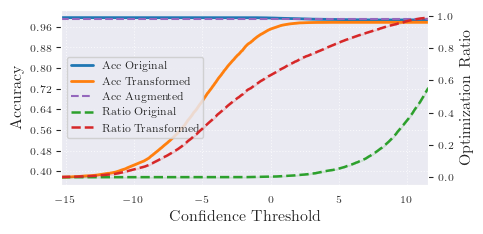

[bigger_mnist]
Max acc (original): 0.9957 @ thr=-2.5952
Max acc (transf.): 0.9776 @ thr=4.7521


In [77]:
test_loader_transformed_quarter = torch.utils.data.DataLoader(
    test_loader_transformed.dataset,
    batch_size=max(dataset_info.batch_size//4,1),
    shuffle=False,
    num_workers=test_loader_transformed.num_workers,
    pin_memory=test_loader_transformed.pin_memory,
    persistent_workers=test_loader_transformed.persistent_workers
)
test_loader_quarter = torch.utils.data.DataLoader(
    test_loader.dataset,
    batch_size=max(dataset_info.batch_size//4,1),
    shuffle=False,
    num_workers=test_loader.num_workers,
    pin_memory=test_loader.pin_memory,
    persistent_workers=test_loader.persistent_workers
)

calculate_confidences_and_cache(
        optimizer=optimizer_120,
        best_problem=problem_energy_half,
        conf_fn=problem_energy_half.confidence_module,
        test_loader=test_loader_quarter,
        test_loader_transformed=test_loader_transformed_quarter,
        device=device,
        n_runs=5,cache_path=cache_path(f"cached_confidences_energy.npz"),
        augment_true_func=None,
    )

    #plot the results
results_energy = np.load(cache_path(f"cached_confidences_energy.npz"), allow_pickle=True)
#compare the two
plot_confidence_threshold_results(results_energy, dataset_name=dataset,save_path= os.path.join(figure_path,"confidence_threshold_energy_vs_base.pdf"),upper_quantile=0.99)



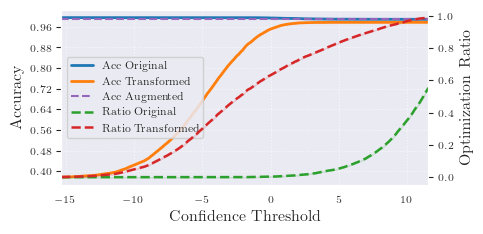

[bigger_mnist]
Max acc (original): 0.9957 @ thr=-2.5952
Max acc (transf.): 0.9776 @ thr=4.7521


In [78]:
plot_confidence_threshold_results(results_energy, dataset_name=dataset,relative_improvement=0.05, save_path= os.path.join(figure_path,"confidence_threshold_energy_vs_base_rel_imp_10.pdf"),upper_quantile=0.99)


Testing loader determinism over the first 5 batches...


Run 2: 100%|██████████| 5/5 [00:00<00:00, 1666.79it/s]


✅ SUCCESS: Data loader is deterministic for the tested batches.
Testing loader determinism over the first 5 batches...


Run 2: 100%|██████████| 5/5 [00:00<00:00, 665.95it/s]

✅ SUCCESS: Data loader is deterministic for the tested batches.
✅ Loading cached results from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\embedding_cache\bigger_mnist\resnet_small\biggermnist_default\cached_confidences_energy_blur_aug.npz_embedding_cache.npz


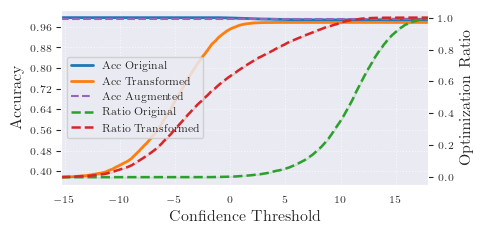

[bigger_mnist]
Max acc (original): 0.9957 @ thr=-2.5652
Max acc (transf.): 0.9772 @ thr=4.6960


In [79]:
if is_image_data:
    calculate_confidences_and_cache(
        optimizer=optimizer_120,
        best_problem=problem_energy_half,
        conf_fn=problem_energy_half.confidence_module,
        test_loader=test_loader_quarter,
        test_loader_transformed=test_loader_transformed_quarter,
        device=device,
        n_runs=5,cache_path=cache_path(f"cached_confidences_energy_blur_aug.npz"),
        augment_true_func=None,
    )

        #plot the results
    results_energy = np.load(cache_path(f"cached_confidences_energy_blur_aug.npz"), allow_pickle=True)
    #compare the two
    plot_confidence_threshold_results(results_energy, dataset_name=dataset,save_path= os.path.join(figure_path,"confidence_threshold_energy_vs_base_augmented.pdf"))



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_augmented.safetensors
=== Calculating base confidences ===


100%|██████████| 79/79 [00:00<00:00, 164.45it/s]



=== Calculating augmented model predictions ===


100%|██████████| 79/79 [00:00<00:00, 176.49it/s]


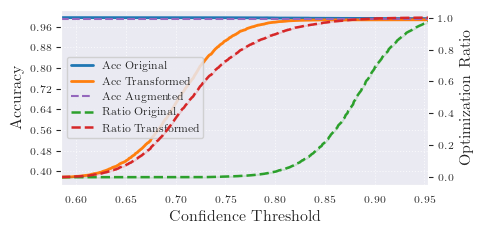

[bigger_mnist]
Max acc (original): 0.9956 @ thr=0.5850
Max acc (transf.): 0.9871 @ thr=0.8653


In [80]:
@torch.no_grad()
def calculate_confidences_and_cache_augmented(
    model_augmented,
    conf_fn,
    test_loader,
    test_loader_transformed,
    device,
    cache_path: str = "cached_confidences.npz",
    force_recompute: bool = False,
):
    """
    Computes and caches:
      - base model: confidence + correctness
      - augmented model: logits + correctness (NO augmented confidence)
    Shapes are kept compatible with optimization-based plotting code.
    """

    # Load cached results
    if os.path.exists(cache_path) and not force_recompute:
        print(f"Loading cached results from {cache_path}")
        return dict(np.load(cache_path, allow_pickle=True))

    print("=== Calculating base confidences ===")

    def eval_base(loader):
        all_conf, correct = [], []

        for x_test, y_test in tqdm.tqdm(loader):
            x_test = x_test.to(device)
            conf_values, logits = conf_fn(x_test)

            pred_y = torch.argmax(logits, dim=1).cpu()
            correct.append((pred_y == y_test).numpy())
            all_conf.append(conf_values.cpu().numpy())

        return np.concatenate(correct), np.concatenate(all_conf)

    def eval_augmented(loader):
        correct = []

        for x_test, y_test in tqdm.tqdm(loader):
            x_test = x_test.to(device)

            logits = model_augmented(x_test)
            pred_y = torch.argmax(logits, dim=1).cpu()

            correct.append((pred_y == y_test).numpy())

        return np.concatenate(correct)

    # Base classifier
    base_correct, base_conf = eval_base(test_loader)
    base_correct_t, base_conf_t = eval_base(test_loader_transformed)

    print("\n=== Calculating augmented model predictions ===")

    aug_correct = eval_augmented(test_loader)
    aug_correct_t = eval_augmented(test_loader_transformed)

    # Make shapes consistent with optimizer output
    aug_correct = aug_correct[:, None]        # (N,1)
    aug_correct_t = aug_correct_t[:, None]    # (N,1)
    base_conf = base_conf[:, None]            # (N,1)
    base_conf_t = base_conf_t[:, None]        # (N,1)

    results = {
        # base model
        "correct_predicted": base_correct,
        "all_conf": base_conf.squeeze(),  # keep original base shape for baseline
        "correct_predicted_transformed": base_correct_t,
        "all_conf_transformed": base_conf_t.squeeze(),

        # augmented model (formatted like optimized runs)
        "optimized_correct_predicted": aug_correct,
        "optimized_correct_predicted_transformed": aug_correct_t,

        # confidence is identical to base, but plotter expects these keys with shape (N,1)
        "optimized_all_conf": base_conf,
        "optimized_all_conf_transformed": base_conf_t,
    }

    np.savez_compressed(cache_path, **results)

    return results



model_augmented = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname_augmented = f"{dataset}_{architecture}_augmented"

train_and_get_model(model_augmented,model_dir_path,modelname_augmented, None, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)

cache_path_augmented = cache_path(f"cached_confidences_augmented_model.npz")

results_augmented = calculate_confidences_and_cache_augmented(
    model_augmented=model_augmented,
    conf_fn=best_problem.confidence_module,
    test_loader=test_loader,
    test_loader_transformed=test_loader_transformed,
    device=device,
    cache_path=cache_path_augmented,
)

plot_confidence_threshold_results(results_augmented, dataset_name=dataset,plot_ratio=True,save_path= os.path.join(figure_path,"confidence_threshold_augmented.pdf"))



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_augmented.safetensors
Loading cached results from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\embedding_cache\bigger_mnist\resnet_small\biggermnist_default\cached_confidences_augmented_model_learned.npz_embedding_cache.npz


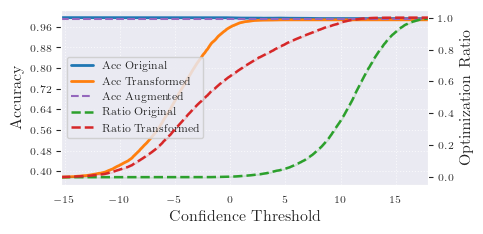

[bigger_mnist]
Max acc (original): 0.9957 @ thr=-2.5652
Max acc (transf.): 0.9871 @ thr=5.6976


In [81]:
@torch.no_grad()
def calculate_confidences_and_cache_augmented(
    model_augmented,
    conf_fn,
    test_loader,
    test_loader_transformed,
    device,
    cache_path: str = "cached_confidences.npz",
    force_recompute: bool = False,
):
    """
    Computes and caches:
      - base model: confidence + correctness
      - augmented model: logits + correctness (NO augmented confidence)
    Shapes are kept compatible with optimization-based plotting code.
    """

    # Load cached results
    if os.path.exists(cache_path) and not force_recompute:
        print(f"Loading cached results from {cache_path}")
        return dict(np.load(cache_path, allow_pickle=True))

    print("=== Calculating base confidences ===")

    def eval_base(loader):
        all_conf, correct = [], []

        for x_test, y_test in tqdm.tqdm(loader):
            x_test = x_test.to(device)
            conf_values, logits = conf_fn(x_test)
            if logits is None:
                logits = model(x_test)

            pred_y = torch.argmax(logits, dim=1).cpu()
            correct.append((pred_y == y_test).numpy())
            all_conf.append(conf_values.cpu().numpy())

        return np.concatenate(correct), np.concatenate(all_conf)

    def eval_augmented(loader):
        correct = []

        for x_test, y_test in tqdm.tqdm(loader):
            x_test = x_test.to(device)

            logits = model_augmented(x_test)
            pred_y = torch.argmax(logits, dim=1).cpu()

            correct.append((pred_y == y_test).numpy())

        return np.concatenate(correct)

    # Base classifier
    base_correct, base_conf = eval_base(test_loader)
    base_correct_t, base_conf_t = eval_base(test_loader_transformed)

    print("\n=== Calculating augmented model predictions ===")

    aug_correct = eval_augmented(test_loader)
    aug_correct_t = eval_augmented(test_loader_transformed)

    # Make shapes consistent with optimizer output
    aug_correct = aug_correct[:, None]        # (N,1)
    aug_correct_t = aug_correct_t[:, None]    # (N,1)
    base_conf = base_conf[:, None]            # (N,1)
    base_conf_t = base_conf_t[:, None]        # (N,1)

    results = {
        # base model
        "correct_predicted": base_correct,
        "all_conf": base_conf.squeeze(),  # keep original base shape for baseline
        "correct_predicted_transformed": base_correct_t,
        "all_conf_transformed": base_conf_t.squeeze(),

        # augmented model (formatted like optimized runs)
        "optimized_correct_predicted": aug_correct,
        "optimized_correct_predicted_transformed": aug_correct_t,

        # confidence is identical to base, but plotter expects these keys with shape (N,1)
        "optimized_all_conf": base_conf,
        "optimized_all_conf_transformed": base_conf_t,
    }

    np.savez_compressed(cache_path, **results)

    return results



model_augmented = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname_augmented = f"{dataset}_{architecture}_augmented"

train_and_get_model(model_augmented,model_dir_path,modelname_augmented, None, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)

cache_path_augmented = cache_path(f"cached_confidences_augmented_model_learned.npz")

results_augmented = calculate_confidences_and_cache_augmented(
    model_augmented=model_augmented,
    conf_fn=problem_energy_half.confidence_module,
    test_loader=test_loader,
    test_loader_transformed=test_loader_transformed,
    device=device,
    cache_path=cache_path_augmented,
)

plot_confidence_threshold_results(results_augmented, dataset_name=dataset,plot_ratio=True,save_path= os.path.join(figure_path,"confidence_threshold_augmented_learned.pdf"))



In [82]:
stop

NameError: name 'stop' is not defined

In [ ]:
# python
threshold = 0.75

# python
import torch
import numpy as np
import tqdm

def eval_threshold_run_remainder(loader, label, threshold, device, conf, optimizer, best_problem):
    n_total = 0
    n_accept = 0
    correct_final = 0
    correct_base = 0


    with torch.no_grad():
        for x_batch, y_batch in tqdm.tqdm(loader, desc=label):
            # ensure tensors
            x_batch = x_batch.to(device)
            y_cpu = y_batch.cpu()  # keep CPU copy for comparisons

            # base confidences and predictions
            conf_vals, logits = conf(x_batch)
            conf_cpu = conf_vals.cpu().view(-1)  # shape (B,)

            base_pred = torch.argmax(logits, dim=1).cpu()
            base_correct = (base_pred == y_cpu)

            # decide which to accept (do NOT optimize) and which to optimize
            accept_mask = conf_cpu >= threshold
            accept_mask_torch = accept_mask.to(device)  # for indexing on device tensors if needed

            # prepare final_correct array (torch bool on CPU)
            final_correct_batch = base_correct.clone()

            # If there are items to optimize, run optimizer on the remainder only
            if (~accept_mask).any():
                # select subset to optimize
                idx_rem = torch.nonzero(~accept_mask, as_tuple=False).squeeze(1)
                x_rem = x_batch[idx_rem]           # already on device
                y_rem_cpu = y_cpu[idx_rem]         # cpu labels

                # run optimizer only on remainder
                p, error, _ = optimizer.optimize(best_problem, x_rem)

                # apply transforms produced by optimizer and recompute confidence/logits
                x_opt = best_problem.transform_sequence.transform(x_rem, p)
                conf_opt_vals, logits_opt = conf(x_opt)
                opt_pred = torch.argmax(logits_opt, dim=1).cpu()
                opt_correct = (opt_pred == y_rem_cpu)

                # place optimized correctness back into final_correct_batch
                final_correct_batch[idx_rem] = opt_correct


            # update accept counters and base counters
            correct_base += int(base_correct.sum().item())
            n_accept += int(accept_mask.sum().item())
            batch_n = final_correct_batch.numel()
            n_total += batch_n
            correct_final += int(final_correct_batch.sum().item())

    acc_final = correct_final / n_total if n_total else float("nan")
    acc_base = correct_base / n_total if n_total else float("nan")

    print(f"{label}: final acc={acc_final:.4f} (accepted={n_accept}, total={n_total})  | base acc={acc_base:.4f}")


print()
threshold = 0.6
eval_threshold_run_remainder(test_loader, "Original test", threshold, device, conf, optimizer, best_problem)
eval_threshold_run_remainder(test_loader_transformed, "Transformed test", threshold, device, conf, optimizer, best_problem)

In [ ]:
conf